In [1]:
# pgf_backend = True
pgf_backend = False

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

if pgf_backend:
    mpl.use("pgf")

In [2]:
# IEEE Access matplotlib settings
# Source: https://journals.ieeeauthorcenter.ieee.org/create-your-ieee-journal-article/create-graphics-for-your-article/resolution-and-size/

font_size = 8

plt.rcParams.update(
    {
        "pgf.rcfonts": False,  # don't use matplotlib defaults
        "pgf.texsystem": "lualatex",  # use LuaLaTeX
        "font.family": "serif",
        "font.serif": ["Times New Roman"],  # system Times New Roman
        "figure.dpi": 300,
        "font.size": font_size,
        "axes.titlesize": font_size,
        "figure.titlesize": font_size,
        "axes.labelsize": font_size,
        "legend.fontsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "pgf.preamble": r"\usepackage{fontspec}\setmainfont{Times New Roman}",
    }
)

# IEEE standard widths (inches)
linewidth_singlecol = 3.5  # single-column figure
linewidth_doublecol = 7.16  # double-column figure
max_height = 9.25  # max text height

golden_ratio = (5**0.5 - 1) / 2

dpi = 300


def set_size(width=linewidth_singlecol, ratio=golden_ratio, height_pad=0):
    height = width * ratio + height_pad
    return (width, min(height, max_height))

In [3]:
data_file_path = "../../data/processed/smard_data_201810010000_202501010000.npz"
data = np.load(data_file_path)
features = torch.tensor(data["features"], dtype=torch.float32).detach().numpy()
targets = torch.tensor(data["targets"], dtype=torch.float32).detach().numpy()
dates = pd.to_datetime(data["dates"])
dates_flat = np.repeat(dates, 24)
dates_flat = dates_flat + pd.to_timedelta(np.arange(0, len(dates_flat)) % 24, unit="h")
dates_flat = dates_flat.to_numpy()


targets_flat = targets.flatten()
load_forecast_flat = features[:, :24].flatten()
renewables_forecast_flat = features[:, 24:48].flatten()

train_date = pd.Timestamp(dates[0])
val_date = pd.Timestamp("2022-12-01")
test_date = pd.Timestamp("2023-12-01")

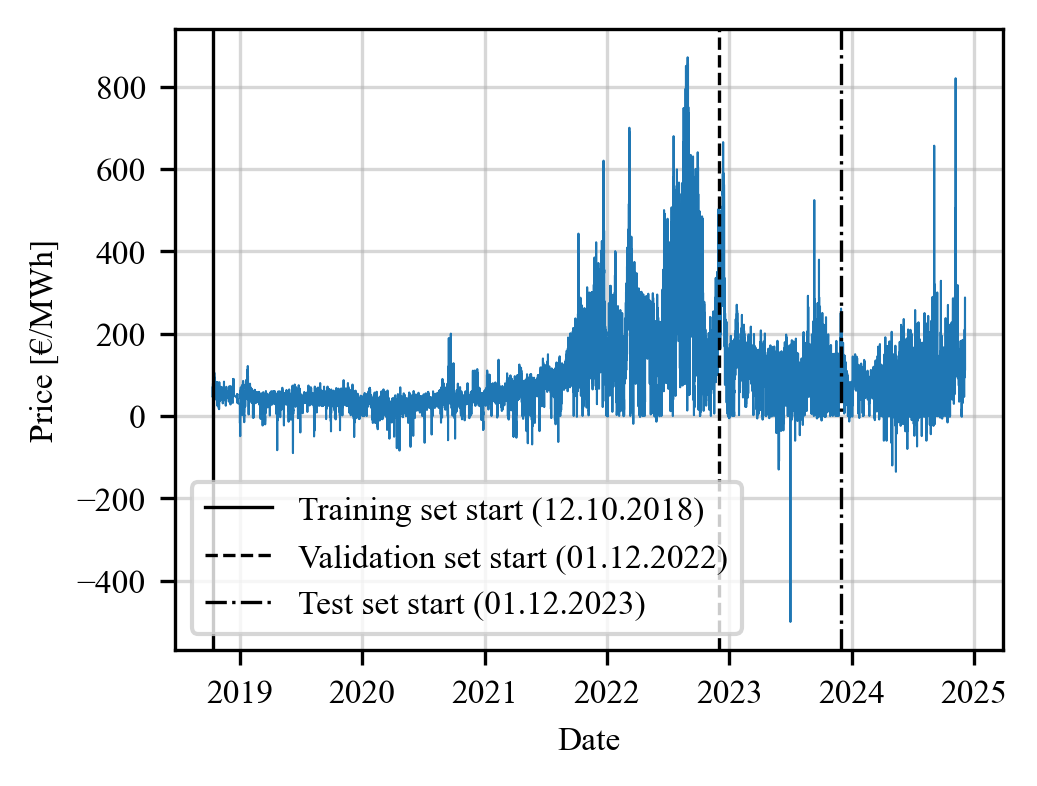

In [4]:
figsize = set_size(height_pad=0.5)
fig, ax = plt.subplots(figsize=figsize)

ax.plot(dates_flat, targets_flat, lw=0.5)

for dt, style, desc in [
    (dates[0], "-", f"Training set start ({train_date.strftime('%d.%m.%Y')})"),
    (val_date, "--", f"Validation set start ({val_date.strftime('%d.%m.%Y')})"),
    (test_date, "-.", f"Test set start ({test_date.strftime('%d.%m.%Y')})"),
]:
    ax.axvline(dt, color="black", linestyle=style, lw=0.8, label=desc)

ax.set_xlabel("Date")
ax.set_ylabel("Price [€/MWh]")
ax.grid(alpha=0.5)
ax.legend()

plt.tight_layout()
if pgf_backend:
    plt.savefig("plots/prices_dataset.pdf", dpi=dpi, bbox_inches="tight")
# plt.show()

In [5]:
# show pdf plot
path = "plots/prices_dataset.pdf"

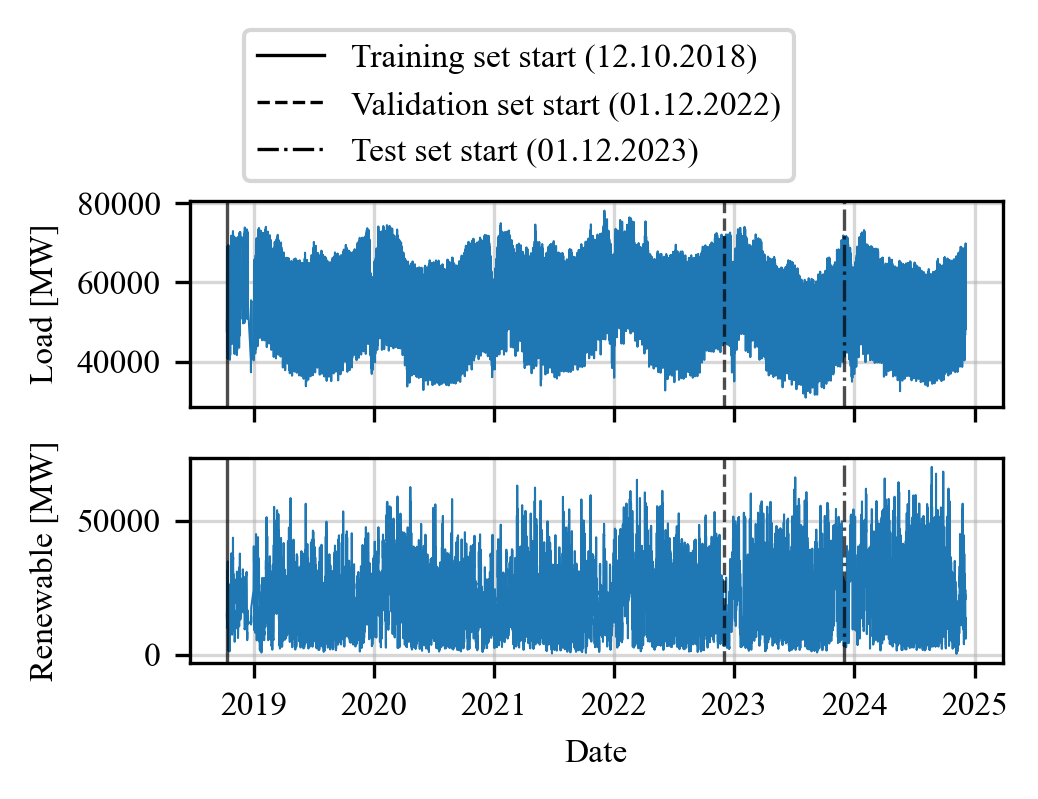

In [6]:
figsize = set_size()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)

# Plot load forecast
ax1.plot(dates_flat, load_forecast_flat, lw=0.5, label="Load Forecast")
ax1.set_ylabel("Load [MW]")
ax1.grid(alpha=0.5)

# Plot renewable forecast
ax2.plot(dates_flat, renewables_forecast_flat, lw=0.5, label="Renewable Forecast")
ax2.set_ylabel("Renewable [MW]")
ax2.set_xlabel("Date")
ax2.grid(alpha=0.5)

# Add vertical lines for dataset splits on all subplots
for ax in [ax1, ax2]:
    for dt, style, desc in [
        (dates[0], "-", f"Training set start ({train_date.strftime('%d.%m.%Y')})"),
        (val_date, "--", f"Validation set start ({val_date.strftime('%d.%m.%Y')})"),
        (test_date, "-.", f"Test set start ({test_date.strftime('%d.%m.%Y')})"),
    ]:
        ax.axvline(dt, color="black", linestyle=style, lw=0.8, alpha=0.7)

# Create legend lines for the legend above plots
legend_lines = []
legend_labels = []
for dt, style, desc in [
    (dates[0], "-", f"Training set start ({train_date.strftime('%d.%m.%Y')})"),
    (val_date, "--", f"Validation set start ({val_date.strftime('%d.%m.%Y')})"),
    (test_date, "-.", f"Test set start ({test_date.strftime('%d.%m.%Y')})"),
]:
    line = plt.Line2D([0], [0], color="black", linestyle=style, lw=0.8)
    legend_lines.append(line)
    legend_labels.append(desc)

# Place legend above the figure
fig.legend(
    legend_lines, legend_labels, bbox_to_anchor=(0.5, 1.22), loc="upper center", ncol=1
)

plt.tight_layout()
if pgf_backend:
    plt.savefig("plots/load_renewables_dataset_v1.pdf", dpi=dpi, bbox_inches="tight")
# plt.show()

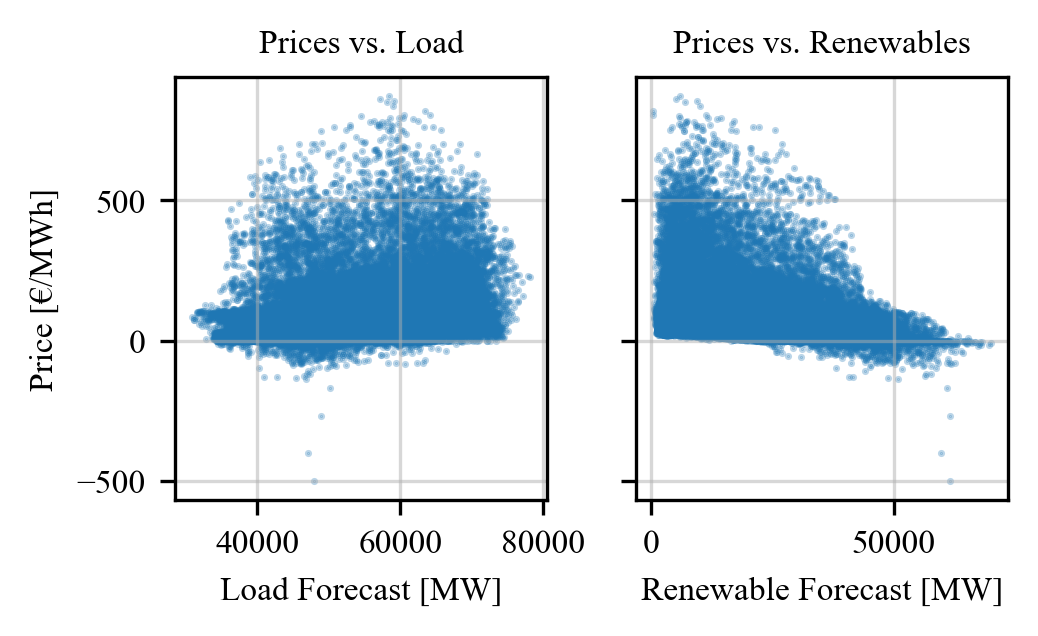

In [7]:
# Create scatter plots showing relationships between prices and load/renewables
figsize = set_size()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)

# Scatter plot: Prices vs Load
ax1.scatter(
    load_forecast_flat, targets_flat, alpha=0.3, s=0.5, rasterized=True
)
ax1.set_xlabel("Load Forecast [MW]")
ax1.set_ylabel("Price [€/MWh]")
ax1.set_title("Prices vs. Load")
ax1.grid(alpha=0.5)

# Scatter plot: Prices vs Renewables
ax2.scatter(
    renewables_forecast_flat,
    targets_flat,
    alpha=0.3,
    s=0.5,
    rasterized=True,
)
ax2.set_xlabel("Renewable Forecast [MW]")
ax2.set_title("Prices vs. Renewables")
ax2.grid(alpha=0.5)

plt.tight_layout()
if pgf_backend:
    plt.savefig(
        "plots/prices_vs_load_renewables_scatter.pdf", dpi=dpi, bbox_inches="tight"
    )
# plt.show()